# 1. Pre_Thickness_VM (전공정 두께 가상계측) — 알고리즘 교육 자료

CMP(Chemical Mechanical Polishing) 공정은 웨이퍼를 투입하기 **직전 두께**를 알아야
얼마나 깎을지(연마 시간 등 APC 파라미터)를 정확히 계산할 수 있습니다.

문제는 CMP 설비가 전공정(Pre-Oper) 장비에서 방금 나온 웨이퍼의 실제 투입 전 두께를
**직접 측정하지 않는다**는 점입니다. 그래서 과거 실적으로부터 전공정 장비/챔버별
두께 편차 패턴을 **학습**해 대신 추정합니다 — 이것이 **Pre_Thk_VM**
(Pre-Thickness Virtual Metrology) 입니다.

이 노트북은 실제 프로덕션 코드 `algorithm_new/Common/PRE_THK_VM.py` 의 함수들을
**그대로 호출**하면서, 각 단계에서 데이터가 어떻게 바뀌는지 하나씩 실행하고
트렌드/테이블로 확인합니다.

**사용 방법: 아래 [실행 설정] 셀에서 `FAMILY` 와 `OPER_DESC` 두 값만 원하는 공정으로
바꾸고 위에서부터 순서대로 실행하면, Set-up 조회 → 데이터 조회 → 경로 판단 →
학습값 산출까지 해당 공정에 맞게 자동으로 진행됩니다.**

```
전체 흐름  (Common/Module.py 의 compute_pre_thk_vm 과 동일한 순서)
────────────────────────────────────────────────────────────────────
 Set-up 조회 (Django DB)  +  merge_df 조회 (MongoDB)
   │
   ├─ [경로 판단]  Set-up 값에 따라 자동 분기
   │      ITM 경로        : Pre_Thk_Para_ITM 설정됨  → BIAS 이동평균
   │      Detrend+MA 경로 : Pre_Oper_Code 설정됨     → compute_detrend + 이동평균
   │      회귀 경로       : Pre_Oper_Code2~4 설정됨  → 전공정 파라미터 선형회귀
   │
   ├─ [Step 1] 학습 대상값 산출 (경로별)
   │      Detrend+MA : compute_detrend() → Detrend_Thk (추세 제거, 0-centered)
   │      ITM        : BIAS 계산 (계측값 0-centering)
   │
   ├─ [Step 2] iqr_filter()        이상치 제거
   │
   ├─ [Step 3] rolling_mean()      pre_eq_ch(전공정 장비_채널)별 기간 이동평균 → Pre_Thk
   │
   ├─ [Step 4] _extract_latest()   채널별 최신 1건 → 최종 학습값
   │
   └─ [Step 5] (설정 시) Pre_Oper2~4 회귀계수 b1/b0 산출
────────────────────────────────────────────────────────────────────
```

## 0. 환경 설정

- `algorithm_new/` 를 import 경로에 추가하고, Jupyter(async 이벤트 루프) 위에서
  Django ORM 동기 쿼리를 허용하도록 `DJANGO_ALLOW_ASYNC_UNSAFE` 를 설정합니다.
- 그래프는 기본 matplotlib 스타일 대신, 여백/그리드/색상을 정돈한 커스텀 스타일
  (`style_ax`, `PALETTE`)을 한 번만 정의하고 이후 모든 그래프에 재사용합니다.

In [1]:
import sys, os
from pathlib import Path

ALGO_DIR = Path('..') / 'algorithm_new'
sys.path.insert(0, str(ALGO_DIR))

# Jupyter 는 async 이벤트 루프 위에서 실행되므로 Django ORM 동기 쿼리 허용
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = '1'

import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)  # findfont 경고 숨김

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ── 한글 폰트 자동 탐색 (Mac/Windows/Linux 어디서 열어도 한글이 깨지지 않도록) ──
_KOREAN_FONTS = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR']
_installed = {f.name for f in font_manager.fontManager.ttflist}
_font = next((f for f in _KOREAN_FONTS if f in _installed), None)
# 한글 폰트를 1순위로, DejaVu Sans를 2순위로 두면 Å 같은 특수기호는
# 한글 폰트에 없어도 자동으로 DejaVu Sans에서 대체 렌더링됨 (matplotlib 폰트 폴백)
plt.rcParams['font.family'] = [_font, 'DejaVu Sans'] if _font else ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ── 깔끔한 트렌드 스타일 (기본 matplotlib 스타일 대신 사용) ──────────────
INK_PRIMARY   = '#0b0b0b'   # 제목/본문
INK_SECONDARY = '#52514e'   # 축 라벨
INK_MUTED     = '#898781'   # 눈금
GRID          = '#e1e0d9'   # 그리드선 (아주 옅게)
BASELINE      = '#c3c2b7'   # 축선
SURFACE       = '#fcfcfb'   # 차트 배경

# 카테고리 색상은 항상 같은 순서로 고정 사용 (장비/채널이 늘어나도 임의로 섞지 않음)
PALETTE = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
           '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']
RAW_COLOR = '#b7d3f6'   # 원본(raw) 산점 — 옅은 블루, MA 라인과 구분

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor'  : SURFACE,
    'axes.edgecolor'  : BASELINE,
    'axes.labelcolor' : INK_SECONDARY,
    'text.color'      : INK_PRIMARY,
    'xtick.color'     : INK_MUTED,
    'ytick.color'     : INK_MUTED,
    'font.size'       : 10,
    'figure.dpi'      : 110,
})

def style_ax(ax, title=None, ylabel=None, xlabel=None, legend=True, legend_loc='best'):
    # 모든 그래프에 공통 적용하는 정돈된 스타일 (spine 정리 + 옅은 그리드 + 좌측 정렬 제목)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(BASELINE)
        ax.spines[spine].set_linewidth(0.8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.tick_params(labelsize=8.5, length=0)
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', color=INK_PRIMARY, loc='left', pad=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8, frameon=False, loc=legend_loc)
    return ax

print(f'환경 설정 완료 (한글 폰트: {_font or "시스템 기본값"})')

환경 설정 완료 (한글 폰트: NanumGothic)


## ★ 실행 설정 — 여기만 수정하세요

| 변수 | 설명 |
|---|---|
| `FAMILY` | `'DRAM'` 또는 `'NAND'` |
| `OPER_DESC` | 공정 설명 (web Set-up 의 Category.oper_desc 와 동일하게) |
| `KEY_INDEX` | 같은 공정에 실행 키(Lot_Code_Oper_Code_Fab)가 여러 개일 때 선택. 아래 [1. Set-up 조회] 결과 표의 번호 |
| `THK_INDEX` | Thk_Para 가 여러 개인 공정(예: ED/CENTER 혼재)일 때 선택. [2. 경로 판단] 결과 표의 번호 |

In [2]:
FAMILY    = 'DRAM'         # ← 원하는 Family
OPER_DESC = 'M1 CU CMP'    # ← 원하는 공정명

KEY_INDEX = 0              # 실행 키가 여러 개일 때 선택 (기본: 첫 번째)
THK_INDEX = 0              # Thk_Para 가 여러 개일 때 선택 (기본: 첫 번째)

print(f'실행 대상: Family={FAMILY} | Oper_Desc={OPER_DESC}')

실행 대상: Family=DRAM | Oper_Desc=M1 CU CMP


## 1. Set-up 조회 & 실행 키 선택

`Get_data.baseinfoGetData()` 가 web Set-up(Django DB: Category / SubCategory / Detail /
RecipeGroup)에서 해당 공정의 전체 Set-up 정보를 읽어옵니다.

운영 코드(`Common/Module.py` 의 `run()`)와 동일하게
**`Lot_Code + Oper_Code + Fab`** 조합으로 실행 키(`for_key_list`)를 만들고,
키가 여러 개면 `KEY_INDEX` 로 하나를 선택합니다.

In [3]:
from Common.Get_Data import Get_data
from Common.PRE_THK_VM import PRE_THK_VM_Get

# ── Set-up 정보 로드 (Django DB) ─────────────────────────────────────
mico_info_table = Get_data.baseinfoGetData(Family=FAMILY, oper_desc=OPER_DESC)
mico_info_table['Group_Name']   = mico_info_table['Group_Name'].fillna('not_group')
mico_info_table['for_key_list'] = (
    mico_info_table['Lot_Code'] + '_' + mico_info_table['Oper_Code'] + '_' + mico_info_table['Fab']
)

# ── 실행 키 목록 표시 ────────────────────────────────────────────────
key_list = mico_info_table['for_key_list'].unique()
key_summary = pd.DataFrame([{
    '실행 키'   : k,
    'Group'     : mico_info_table.loc[mico_info_table['for_key_list'] == k, 'Group_Name'].iloc[0],
    'Recipe 수' : mico_info_table.loc[mico_info_table['for_key_list'] == k, 'Recipe_ID'].nunique(),
    'Detail 행' : (mico_info_table['for_key_list'] == k).sum(),
} for k in key_list])
print(f'실행 키 {len(key_list)}개 (KEY_INDEX={KEY_INDEX} 선택됨)')
display(key_summary)

# ── KEY_INDEX 로 실행 키 선택 ────────────────────────────────────────
assert 0 <= KEY_INDEX < len(key_list), f'KEY_INDEX 는 0 ~ {len(key_list)-1} 범위로 지정하세요'
FOR_KEY       = key_list[KEY_INDEX]
mico_info_key = mico_info_table[mico_info_table['for_key_list'] == FOR_KEY].copy()

Fab       = mico_info_key['Fab'].unique()[0]
Lot_Code  = mico_info_key['Lot_Code'].unique()[0]
Oper_Code = mico_info_key['Oper_Code'].unique()[0]
Oper_Desc = mico_info_key['Oper_Desc'].unique()[0]
Family    = mico_info_key['Family'].unique()[0]

# pol_type: Category.pol_type (web DB set-up 값) — Module.py _run_pipeline 과 동일
pol_type_vals = mico_info_key['Pol_Type'].dropna().unique()
pol_type = int(pol_type_vals[0]) if len(pol_type_vals) > 0 else None

print(f'\n선택된 키: {FOR_KEY}  (pol_type={pol_type})')
mico_info_key[['Recipe_ID', 'APC_Para', 'Thk_Para', 'Target', 'Pre_Target',
               'Pre_Thk_Period', 'FB_Type', 'Pre_Thk_Para_ITM', 'Pre_Oper_Code', 'Pre_Oper_Code2']]

실행 키 1개 (KEY_INDEX=0 선택됨)


,실행 키,Group,Recipe 수,Detail 행
0,LC_V5077000E_M10,not_group,2,2



선택된 키: LC_V5077000E_M10  (pol_type=3)


,Recipe_ID,APC_Para,Thk_Para,Target,Pre_Target,Pre_Thk_Period,FB_Type,Pre_Thk_Para_ITM,Pre_Oper_Code,Pre_Oper_Code2
0,E2_M1CU_R12_TSV.CAS,P3,AMAT_POST_OCD_AVG,1900,2350,3,TIME,,A111111B,
1,E2_M1CU_R17_TSV.CAS,P3,AMAT_POST_OCD_AVG,1900,2350,3,TIME,,A111111B,


## 2. CMP 실측 데이터(merge_df) 조회

`Get_data.MongoDB_GetData()` 로 해당 공정의 CMP 실측 데이터를 조회합니다.
(로컬 테스트 환경에서는 이 함수가 `merge_df_sample.csv` 를 대신 읽도록 되어 있고,
회사 서버에서는 실제 MongoDB 쿼리가 실행됩니다 — 노트북 코드는 동일합니다.)

조회 후 운영 코드(`_run_single`)와 동일하게 `operation_id == Oper_Code` 로 필터링합니다.

In [4]:
merge_df = Get_data.MongoDB_GetData(Family, Fab, Lot_Code, Oper_Desc)
assert merge_df is not None and not merge_df.empty, '조회된 데이터가 없습니다. Set-up/기간을 확인하세요.'

merge_df['IDLE'] = merge_df['IDLE'].fillna('')
merge_df = merge_df[merge_df['operation_id'] == Oper_Code].copy()
assert not merge_df.empty, f'operation_id == {Oper_Code} 데이터가 없습니다.'

print(f'merge_df : {merge_df.shape[0]:,}행  (기간 {merge_df["Date"].min()} ~ {merge_df["Date"].max()})')
print(f'CMP 장비 : {sorted(merge_df["eqp_id"].unique())}')
print(f'레시피   : {sorted(merge_df["recipe_id"].unique())}')
if 'pre_eqp_id' in merge_df.columns:
    n_ch = (merge_df['pre_eqp_id'].astype(str) + '_' + merge_df['pre_eqp_ch'].astype(str)).nunique()
    print(f'전공정 장비_채널 조합 : {n_ch}개')
merge_df.head(3)

merge_df : 20,000행  (기간 2026-04-16 00:10:43.490142 ~ 2026-05-16 23:00:00)
CMP 장비 : ['KCMP41', 'KCMP42', 'KCMP43', 'KCMP44', 'KCMP45']
레시피   : ['E2_M1CU_R12_TSV.CAS', 'E2_M1CU_R17_TSV.CAS']
전공정 장비_채널 조합 : 16개


,Date,process_id,recipe_id,eqp_id,eqp_model,operation_id,oper_id,oper_det_desc,item_name,r2r_rank,...,AMAT_POST_OCD_Z2_AVG,AMAT_POST_OCD_Z3_AVG,AMAT_POST_OCD_Z4_AVG,AMAT_POST_OCD_Z5_AVG,IDLE,rank,event_tm,before_recipe_id,brfore_info,Lot_Code
0,2026-04-16 00:10:43.490142,F_6E2_01,E2_M1CU_R17_TSV.CAS,KCMP43,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1920.01,1960.99,1964.00,1966.76,Layer_1,1,-,-,-,LC
1,2026-04-16 00:10:48.090503,F_6E2_01,E2_M1CU_R12_TSV.CAS,KCMP44,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1941.08,1869.22,1908.63,1947.51,Layer_1,1,-,-,-,LC
2,2026-04-16 00:10:55.654347,F_6E2_01,E2_M1CU_R17_TSV.CAS,KCMP42,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1943.46,1897.90,1930.90,1970.02,Idle_1,1,-,-,-,LC


## 3. Thk_Para 선택 & 실행 경로 판단

`Common/Module.py` 의 `compute_pre_thk_vm()` 은 Set-up 값에 따라 자동으로 아래 3가지
중 하나(또는 조합)로 분기합니다. **아래 셀이 이 공정의 Set-up 을 읽어 자동으로 같은
판단을 내립니다.**

| 경로 | 조건 | 학습 대상값 (y) |
|---|---|---|
| **ITM** | `Pre_Thk_Para_ITM` 설정됨 (전공정 계측값 존재) | `BIAS` (계측값 0-centering) |
| **Detrend + MA** | `Pre_Oper_Code` 설정됨 | `Detrend_Thk` (추세 제거) |
| **Pre_Oper2~4 회귀** | `Pre_Oper_Code2` 설정됨 | 위 값을 y 로 선형회귀 |

한 실행 키 안에 `Thk_Para` 가 여러 개일 수 있어(예: DRAM STI 처럼 ED/CENTER 혼재)
운영 코드는 Thk_Para 별로 루프를 돕니다. 이 노트북은 교육을 위해 `THK_INDEX` 로
하나를 골라 그 흐름을 따라갑니다.

In [5]:
# ── Thk_Para 선택 ────────────────────────────────────────────────────
thk_para_list = mico_info_key['Thk_Para'].unique()
print(f'Thk_Para 목록 ({len(thk_para_list)}개):')
for i, t in enumerate(thk_para_list):
    mark = ' ← 선택됨' if i == THK_INDEX else ''
    print(f'  [{i}] {t}{mark}')

assert 0 <= THK_INDEX < len(thk_para_list), f'THK_INDEX 는 0 ~ {len(thk_para_list)-1} 범위로 지정하세요'
Thk_Para = thk_para_list[THK_INDEX]
key_df   = mico_info_key[mico_info_key['Thk_Para'] == Thk_Para].copy()

# ── 경로 판단 (Module.py compute_pre_thk_vm 과 동일한 로직) ──────────
itm_paras = key_df['Pre_Thk_Para_ITM'].dropna()
itm_paras = itm_paras[itm_paras != ''].unique()
use_itm   = len(itm_paras) > 0

ref_key        = key_df.iloc[0]
Pre_Oper_Code2 = ref_key['Pre_Oper_Code2']

pre_oper_vals  = key_df['Pre_Oper_Code'].dropna()
use_moving_avg = (not use_itm) and len(pre_oper_vals[pre_oper_vals != '']) > 0
has_regression = isinstance(Pre_Oper_Code2, str) and Pre_Oper_Code2 != ''

path  = 'ITM' if use_itm else ('Detrend' if use_moving_avg else '')
path += '+MA'   if use_moving_avg else ''
path += '+회귀' if has_regression else ''

print(f'\n판단 결과 — Thk_Para={Thk_Para}')
print(f'  ITM 경로         : {use_itm}')
print(f'  Detrend+MA 경로  : {use_moving_avg}')
print(f'  Pre_Oper2~4 회귀 : {has_regression}')
print(f'  → 실행 경로: {path if path else "없음 (학습 불필요 — Set-up 확인 필요)"}')

assert use_itm or use_moving_avg or has_regression, 'ITM/Pre_Oper_Code/Pre_Oper_Code2 모두 미설정 → Pre_Thk_VM 학습 대상이 아닙니다.'

Thk_Para 목록 (1개):
  [0] AMAT_POST_OCD_AVG ← 선택됨

판단 결과 — Thk_Para=AMAT_POST_OCD_AVG
  ITM 경로         : False
  Detrend+MA 경로  : True
  Pre_Oper2~4 회귀 : False
  → 실행 경로: Detrend+MA


## 4. 공통 파라미터 추출

Set-up(key_df)에서 계산에 필요한 파라미터를 꺼냅니다. 모두 운영 코드와 동일한
방식입니다.

- `Thk_Para_13P` / `Target_13P` : `FB_Type == 'TIME'` 인 기준 파라미터/타깃.
  PRESSURE(ED/EX) 파라미터는 이 기준 대비 편차(BIAS)로 0-centering 합니다.
- `min_count` : Thk_Para 이름에 `ED`/`EX` 가 포함되면 5, 아니면 10
  (엣지 계측은 샘플 수가 적어 기준을 낮춤)

In [6]:
Pre_Thk_Period = str(mico_info_key['Pre_Thk_Period'].unique()[0]) + 'D'
Thk_Para_13P   = mico_info_key[mico_info_key['FB_Type'] == 'TIME']['Thk_Para'].unique()[0]
min_count      = 5 if ('ED' in Thk_Para or 'EX' in Thk_Para) else 10

print(f'Thk_Para       : {Thk_Para}')
print(f'Thk_Para_13P   : {Thk_Para_13P}  (FB_Type=TIME 기준 파라미터)')
print(f'Pre_Thk_Period : {Pre_Thk_Period}  (이동평균 윈도우)')
print(f'min_count      : {min_count}  (이동평균 최소 데이터 수)')
print()
print('Recipe 별 Set-up:')
key_df[['Recipe_ID', 'APC_Para', 'Target', 'Pre_Target', 'FB_Type']]

Thk_Para       : AMAT_POST_OCD_AVG
Thk_Para_13P   : AMAT_POST_OCD_AVG  (FB_Type=TIME 기준 파라미터)
Pre_Thk_Period : 3D  (이동평균 윈도우)
min_count      : 10  (이동평균 최소 데이터 수)

Recipe 별 Set-up:


,Recipe_ID,APC_Para,Target,Pre_Target,FB_Type
0,E2_M1CU_R12_TSV.CAS,P3,1900,2350,TIME
1,E2_M1CU_R17_TSV.CAS,P3,1900,2350,TIME


## Step 1 — 학습 대상값 산출 (경로별 자동 분기)

이 셀은 위 [3. 경로 판단] 결과에 따라 **해당 공정에 맞는 경로의 코드만** 실행합니다.
두 경로 모두 결과는 "0-centered 학습 대상값" 컬럼(`value_col`)이 붙은 DataFrame 입니다.

### (A) Detrend + MA 경로 — `compute_detrend()`

```python
# PRE_THK_VM.py  compute_detrend()  핵심 로직
Pol_Time  = APC_Para_merge 합                      # 총 연마 시간
RR        = (Pre_Target - Thk) / Pol_Time          # 실측 연마율
FIX_Time  = 전체 평균 Pol_Time                      # 장비 공통 기준 연마시간

for (eqp, recipe) 조합:
    Unctr_Thk  = Pre_Target - (RR * FIX_Time)      # "고정 시간 기준" 두께로 역산
    pad_cycle  = (Pad_Para 급감 시점) 기준 구간 번호  # 패드 교체 시점 분리
    Unctr_Thk_MA = 사이클별 rolling(10) 평균
    Detrend_Thk  = Unctr_Thk - Unctr_Thk_MA        # 추세 제거 → 0-centered
```

**왜 이렇게 계산할까?** 실제 연마 시간은 APC가 매 웨이퍼마다 다르게 조정하므로,
두께 원본값만 보면 "APC가 잘 조정한 결과"와 "전공정 두께 편차"가 섞여 있습니다.
연마 시간을 고정값(FIX_Time)으로 통일해 두께를 역산하면 APC 보정 효과가 제거되어,
남은 변동은 전공정에서 온 두께 편차(드리프트)만 남습니다.

### (B) ITM 경로 — BIAS 계산

전공정 계측값(`Pre_Thk_Para_ITM`)이 이미 존재하므로 detrend 없이 계측값을
0-centering 한 `BIAS` 를 바로 학습 대상값으로 사용합니다.
`FB_Type=PRESSURE` 가 섞여 있으면 두 계측 파라미터 간 차이를 0-centering 합니다.

In [7]:
if use_moving_avg:
    # ══ (A) Detrend + MA 경로 — Module.py 의 루프 코드와 동일 ══════════════
    # 같은 Thk_Para 에 Recipe/APC_Para 가 여러 행일 수 있으므로 행별로 compute_detrend 후 합산
    pre_df    = pd.DataFrame()
    value_col = 'Detrend_Thk'

    for i in range(len(key_df)):
        key          = key_df.iloc[i]
        APC_Para     = key['APC_Para']
        Recipe_ID    = key['Recipe_ID']
        Pre_Target   = float(key['Pre_Target'])
        Post_Target  = float(key['Target'])
        use_pressure = key['FB_Type'] == 'PRESSURE'
        Target_13P   = mico_info_key[(mico_info_key['Recipe_ID'] == Recipe_ID) &
                                     (mico_info_key['FB_Type'] == 'TIME')]['Target'].unique()[0]

        merge_df['BIAS'] = (merge_df[Thk_Para] - merge_df[Thk_Para_13P]) - (Post_Target - float(Target_13P))
        Pad_Para         = Get_data.PadParaGet(APC_Para)
        APC_Para_merge   = Get_data.APCParaGet(APC_Para, pol_type)

        print(f'compute_detrend 실행: APC_Para={APC_Para} | Recipe={Recipe_ID} | '
              f'Pre_Target={Pre_Target} | Post_Target={Post_Target} | use_pressure={use_pressure}')
        part = PRE_THK_VM_Get.compute_detrend(
            merge_df, APC_Para_merge, Thk_Para, Pre_Target, Post_Target, Pad_Para,
            use_pressure=use_pressure
        )
        part['THK_Para'] = Thk_Para
        pre_df = part if pre_df.empty else pd.concat([pre_df, part])

    print(f'\n결과: {len(pre_df):,}행  |  장비x레시피 조합 {pre_df.groupby(["eqp_id","recipe_id"]).ngroups}개')
    print(f'Detrend_Thk 결측 {pre_df["Detrend_Thk"].isna().sum()}건 (사이클 초반, MA 미산출)')
    display(pre_df[['Date', 'eqp_id', 'recipe_id', 'Pol_Time', 'RR',
                    'Unctr_Thk', 'pad_cycle', 'Unctr_Thk_MA', 'Detrend_Thk']].head(8))

elif use_itm:
    # ══ (B) ITM 경로 — Module.py 의 ITM 분기 코드와 동일 ══════════════════
    pre_df    = merge_df.copy()
    value_col = 'BIAS'

    Pre_Thk_Para = itm_paras[0]
    itm_rows     = key_df[key_df['Pre_Thk_Para_ITM'].notna() & (key_df['Pre_Thk_Para_ITM'] != '')]
    use_pressure = (itm_rows['FB_Type'] == 'PRESSURE').any()

    itm_13p_rows = mico_info_key[
        (mico_info_key['FB_Type'] == 'TIME') &
        mico_info_key['Pre_Thk_Para_ITM'].notna() & (mico_info_key['Pre_Thk_Para_ITM'] != '')
    ]
    Pre_Thk_Para_13P = itm_13p_rows['Pre_Thk_Para_ITM'].unique()[0] if len(itm_13p_rows) > 0 else None

    if use_pressure:
        # Pressure ITM(ED/EX): 두 계측 파라미터 간 차이를 0-centering
        pre_df['BIAS'] = (
            pre_df[Pre_Thk_Para] - pre_df[Pre_Thk_Para_13P]
            - (pre_df[Pre_Thk_Para].mean() - pre_df[Pre_Thk_Para_13P].mean())
        )
        print(f'ITM(PRESSURE): BIAS = ({Pre_Thk_Para} - {Pre_Thk_Para_13P}) 0-centering')
    else:
        # 그 외 ITM: Pre_Thk_Para 단독 0-centering
        pre_df['BIAS'] = pre_df[Pre_Thk_Para] - pre_df[Pre_Thk_Para].mean()
        print(f'ITM: BIAS = {Pre_Thk_Para} - mean  (0-centering)')

    print(f'\n결과: {len(pre_df):,}행  |  BIAS 평균 {pre_df["BIAS"].mean():.3f} (0이어야 정상) | 표준편차 {pre_df["BIAS"].std():.2f}')
    display(pre_df[['Date', 'eqp_id', 'recipe_id', Pre_Thk_Para, 'BIAS']].head(8))

else:
    # 회귀 전용 경로 (pre_oper1 미설정): BIAS 를 y 로 직접 회귀 — Step 2~4 는 건너뜀
    ref          = key_df.iloc[0]
    use_pressure = (key_df['FB_Type'] == 'PRESSURE').any()
    if use_pressure:
        Post_Target = float(ref['Target'])
        Target_13P  = mico_info_key[(mico_info_key['Recipe_ID'] == ref['Recipe_ID']) &
                                    (mico_info_key['FB_Type'] == 'TIME')]['Target'].unique()[0]
        merge_df['BIAS'] = (merge_df[Thk_Para] - merge_df[Thk_Para_13P]) - (Post_Target - float(Target_13P))
    else:
        merge_df['BIAS'] = merge_df[Thk_Para] - merge_df[Thk_Para].mean()
    pre_df    = merge_df[['substrate_id', 'BIAS']].dropna().copy()
    value_col = 'BIAS'
    print(f'회귀 전용 경로: BIAS {len(pre_df):,}행 산출 — Step 2~4 는 건너뛰고 Step 5(회귀)만 수행합니다.')

compute_detrend 실행: APC_Para=P3 | Recipe=E2_M1CU_R12_TSV.CAS | Pre_Target=2350.0 | Post_Target=1900.0 | use_pressure=False


compute_detrend 실행: APC_Para=P3 | Recipe=E2_M1CU_R17_TSV.CAS | Pre_Target=2350.0 | Post_Target=1900.0 | use_pressure=False

결과: 38,060행  |  장비x레시피 조합 10개
Detrend_Thk 결측 612건 (사이클 초반, MA 미산출)


,Date,eqp_id,recipe_id,Pol_Time,RR,Unctr_Thk,pad_cycle,Unctr_Thk_MA,Detrend_Thk
0,2026-04-16 01:29:55.304633,KCMP45,E2_M1CU_R12_TSV.CAS,18.213,18.830033,1821.631300,1,NaN,NaN
1,2026-04-16 01:41:03.831303,KCMP45,E2_M1CU_R12_TSV.CAS,23.702,17.422876,1861.115995,1,NaN,NaN
2,2026-04-16 01:52:19.576705,KCMP45,E2_M1CU_R12_TSV.CAS,20.251,22.831959,1709.337706,1,NaN,NaN
3,2026-04-16 02:26:09.215869,KCMP45,E2_M1CU_R12_TSV.CAS,23.366,18.959407,1818.001098,1,NaN,NaN
4,2026-04-16 02:37:52.301595,KCMP45,E2_M1CU_R12_TSV.CAS,21.805,18.619436,1827.540645,1,NaN,NaN
5,2026-04-16 03:10:36.201863,KCMP45,E2_M1CU_R12_TSV.CAS,20.305,18.642684,1826.888304,1,NaN,NaN
6,2026-04-16 03:21:54.119602,KCMP45,E2_M1CU_R12_TSV.CAS,23.723,19.904308,1791.487272,1,NaN,NaN
7,2026-04-16 03:32:34.816249,KCMP45,E2_M1CU_R12_TSV.CAS,22.184,17.629287,1855.324120,1,NaN,NaN


### Step 1 시각화 — 학습 대상값이 어떻게 만들어졌는가

Detrend+MA 경로면 **대표 장비 1대**(데이터가 가장 많은 장비×레시피 조합)의
패드 사이클 분리 → 이동평균 → 추세 제거 과정을 3단으로 보여주고,
ITM 경로면 BIAS 트렌드를 보여줍니다. (대표 장비는 자동 선택됩니다.)

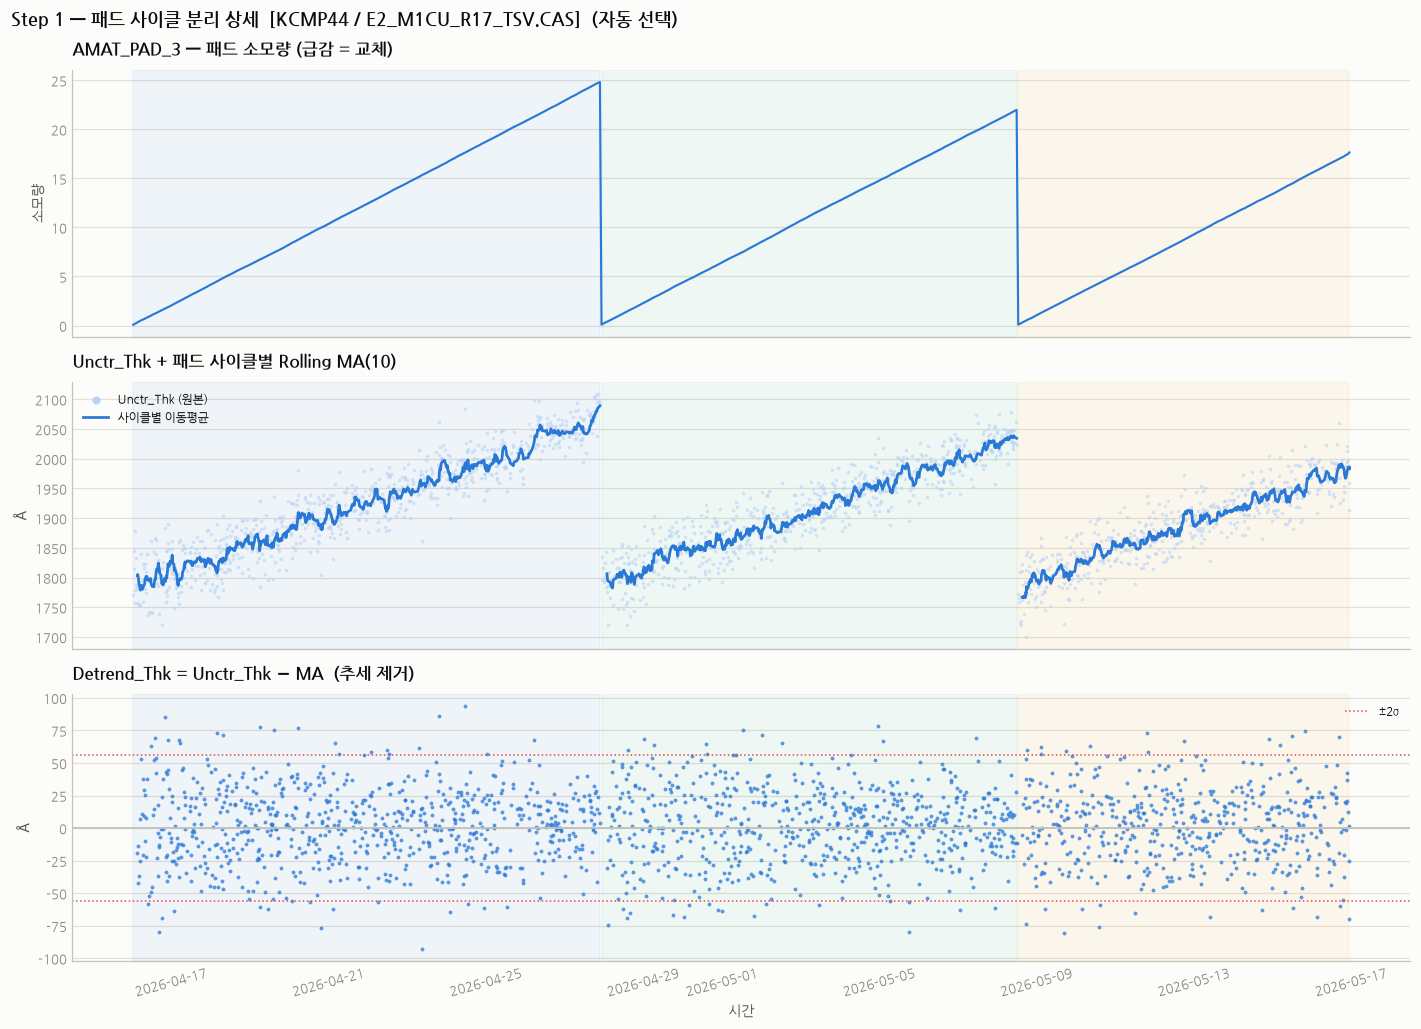

Detrend_Thk 평균 1.68 (0에 근접해야 정상)  |  표준편차 28.09


In [8]:
if use_moving_avg:
    # ── 대표 장비×레시피 자동 선택 (데이터 최다 조합) ──────────────────
    combo = pre_df.groupby(['eqp_id', 'recipe_id']).size().idxmax()
    DEMO_EQP, DEMO_RCP = combo
    demo = pre_df[(pre_df.eqp_id == DEMO_EQP) & (pre_df.recipe_id == DEMO_RCP)] \
            .sort_values('Date').reset_index(drop=True)
    cycles   = sorted(demo['pad_cycle'].unique())
    Pad_Para = Get_data.PadParaGet(key_df.iloc[0]['APC_Para'])

    fig, axes = plt.subplots(3, 1, figsize=(13, 9.5), sharex=True)
    fig.suptitle(f'Step 1 — 패드 사이클 분리 상세  [{DEMO_EQP} / {DEMO_RCP}]  (자동 선택)',
                 fontsize=12, fontweight='bold', color=INK_PRIMARY, x=0.01, ha='left')

    bounds = demo.groupby('pad_cycle')['Date'].agg(['min', 'max'])
    for ax in axes:
        for cyc, row in bounds.iterrows():
            ax.axvspan(row['min'], row['max'], color=PALETTE[(int(cyc) - 1) % len(PALETTE)], alpha=0.06)

    ax = axes[0]
    ax.plot(demo['Date'], demo[Pad_Para], color=PALETTE[0], linewidth=1.4)
    style_ax(ax, title=f'{Pad_Para} — 패드 소모량 (급감 = 교체)', ylabel='소모량', legend=False)

    ax = axes[1]
    for cyc in cycles:
        c = demo[demo.pad_cycle == cyc]
        ax.scatter(c['Date'], c['Unctr_Thk'], s=5, alpha=0.35, color=RAW_COLOR, linewidths=0)
        c_ma = c.dropna(subset=['Unctr_Thk_MA'])
        if len(c_ma) > 1:
            ax.plot(c_ma['Date'], c_ma['Unctr_Thk_MA'], color=PALETTE[0], linewidth=1.8)
    ax.scatter([], [], s=18, color=RAW_COLOR, label='Unctr_Thk (원본)')
    ax.plot([], [], color=PALETTE[0], linewidth=1.8, label='사이클별 이동평균')
    style_ax(ax, title='Unctr_Thk + 패드 사이클별 Rolling MA(10)', ylabel='Å')

    ax = axes[2]
    det = demo.dropna(subset=['Detrend_Thk'])
    sigma = det['Detrend_Thk'].std()
    ax.scatter(det['Date'], det['Detrend_Thk'], s=6, alpha=0.5, color=PALETTE[0], linewidths=0)
    ax.axhline(0, color=BASELINE, linewidth=1.2)
    ax.axhline(2 * sigma, color=PALETTE[5], linewidth=1, linestyle=':')
    ax.axhline(-2 * sigma, color=PALETTE[5], linewidth=1, linestyle=':', label='±2σ')
    style_ax(ax, title='Detrend_Thk = Unctr_Thk − MA  (추세 제거)', ylabel='Å', xlabel='시간')
    axes[-1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()
    print(f'Detrend_Thk 평균 {det["Detrend_Thk"].mean():.2f} (0에 근접해야 정상)  |  표준편차 {sigma:.2f}')

elif use_itm:
    # ── ITM 경로: 장비별 BIAS 트렌드 ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for i, eqp in enumerate(sorted(pre_df['eqp_id'].unique())):
        sub = pre_df[pre_df.eqp_id == eqp].sort_values('Date')
        ax.scatter(sub['Date'], sub['BIAS'], s=5, alpha=0.4,
                   color=PALETTE[i % len(PALETTE)], linewidths=0, label=eqp)
    ax.axhline(0, color=BASELINE, linewidth=1.2)
    style_ax(ax, title=f'BIAS 트렌드 (ITM: {itm_paras[0]} 0-centering)', ylabel='BIAS', xlabel='시간')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

else:
    print('회귀 전용 경로 — 이 단계는 해당 없음')

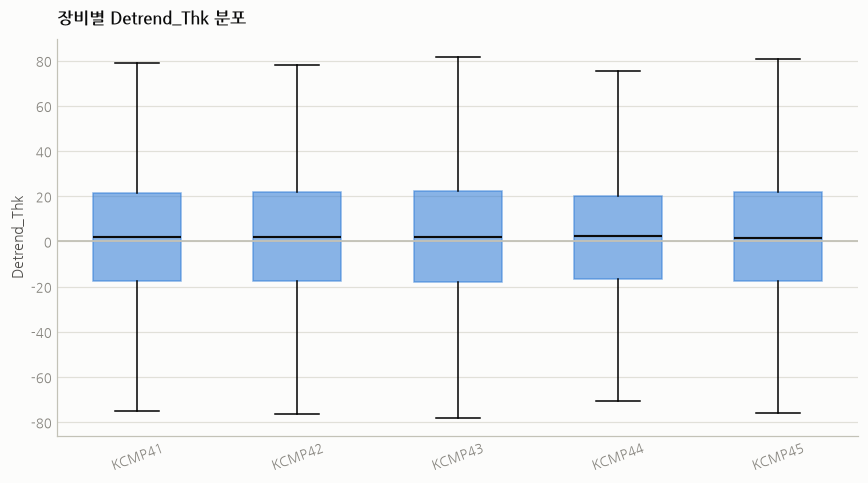

In [9]:
# ── 장비별 학습 대상값 분포 비교 (경로 공통) ───────────────────────────
if (use_moving_avg or use_itm) and 'eqp_id' in pre_df.columns:
    dist = pre_df.dropna(subset=[value_col])
    eqp_list = sorted(dist['eqp_id'].unique())

    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(eqp_list)), 4.5))
    bp = ax.boxplot([dist[dist.eqp_id == e][value_col].values for e in eqp_list],
                    tick_labels=eqp_list, patch_artist=True, showfliers=False, widths=0.55,
                    medianprops=dict(color=INK_PRIMARY, linewidth=1.4))
    for patch in bp['boxes']:
        patch.set_facecolor(PALETTE[0]); patch.set_alpha(0.55); patch.set_edgecolor(PALETTE[0])
    ax.axhline(0, color=BASELINE, linewidth=1.2)
    style_ax(ax, title=f'장비별 {value_col} 분포', ylabel=value_col, legend=False)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print('회귀 전용 경로 — 이 단계는 해당 없음')

## Step 2 — `iqr_filter()` : 이상치 제거

```python
q1, q3 = df[col].quantile([0.25, 0.75])
IQR    = q3 - q1
return df[(df[col] >= q1 - sigma*IQR) & (df[col] <= q3 + sigma*IQR)]   # sigma=3
```

평균/표준편차 방식은 이상치 자체가 평균·표준편차를 왜곡시키지만, IQR(사분위 범위)
방식은 중앙 50% 데이터만 기준으로 삼기 때문에 극단값에 흔들리지 않습니다.
`sigma=3` 은 정규분포 기준 약 99.7% 데이터를 보존하는 수준입니다.

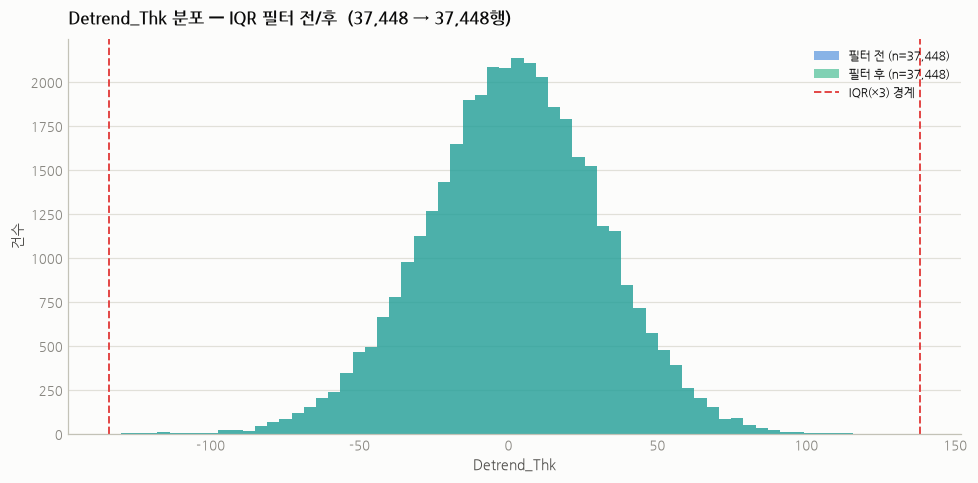

IQR 경계: LCL=-134.2, UCL=138.2  |  제거 0건 (0.00%)


In [10]:
if use_moving_avg or use_itm:
    pre_df_filtered = PRE_THK_VM_Get.iqr_filter(pre_df, value_col)

    before = pre_df[value_col].dropna()
    after  = pre_df_filtered[value_col]
    q1, q3 = before.quantile([0.25, 0.75]); iqr = q3 - q1
    lcl, ucl = q1 - 3 * iqr, q3 + 3 * iqr

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(before, bins=60, color=PALETTE[0], alpha=0.55, label=f'필터 전 (n={len(before):,})')
    ax.hist(after,  bins=60, color=PALETTE[1], alpha=0.55, label=f'필터 후 (n={len(after):,})')
    ax.axvline(lcl, color=PALETTE[5], linewidth=1.3, linestyle='--')
    ax.axvline(ucl, color=PALETTE[5], linewidth=1.3, linestyle='--', label='IQR(×3) 경계')
    style_ax(ax, title=f'{value_col} 분포 — IQR 필터 전/후  ({len(before):,} → {len(after):,}행)',
             xlabel=value_col, ylabel='건수')
    plt.tight_layout()
    plt.show()
    print(f'IQR 경계: LCL={lcl:.1f}, UCL={ucl:.1f}  |  제거 {len(before) - len(after)}건 '
          f'({(len(before) - len(after)) / len(before) * 100:.2f}%)')
else:
    pre_df_filtered = pre_df
    print('회귀 전용 경로 — 이 단계는 건너뜁니다')

## Step 3 — `rolling_mean()` : 전공정 채널별 이동평균 → Pre_Thk

```python
df['pre_eq_ch'] = df['pre_eqp_id'] + '_' + df['pre_eqp_ch']    # 전공정 장비_채널 키

for pre_eq_ch 별:
    Pre_Thk       = value_col 의 rolling(window=Pre_Thk_Period, on='pre_oper_time').mean()
    Pre_Thk_Count = 같은 윈도우의 유효 건수
```

`pre_oper_time`(전공정 처리 시각) 기준으로 최근 `Pre_Thk_Period` 동안의 학습 대상값
평균이 그 채널의 **Pre_Thk 학습값**입니다. 데이터가 `min_count` 건 미만이면 아직
신뢰할 수 없다고 보고 결측(NaN) 처리합니다. ITM/Detrend 두 경로가 **같은 함수**를
사용합니다 (`value_col` 만 다름).

In [11]:
if use_moving_avg or use_itm:
    pre_df_rolled = PRE_THK_VM_Get.rolling_mean(pre_df_filtered, value_col, Pre_Thk_Period, min_count=min_count)

    valid = pre_df_rolled.dropna(subset=['Pre_Thk'])
    print(f'rolling_mean 결과 : {len(pre_df_rolled):,}행')
    print(f'pre_eq_ch 채널 수 : {pre_df_rolled["pre_eq_ch"].nunique()}개')
    print(f'Pre_Thk 유효 건수 : {len(valid):,}행 (min_count={min_count} 미달 구간은 NaN)')
    display(valid.groupby('pre_eq_ch').size().sort_values(ascending=False).rename('유효 건수').to_frame())
else:
    print('회귀 전용 경로 — 이 단계는 건너뜁니다')

rolling_mean 결과 : 37,448행
pre_eq_ch 채널 수 : 16개
Pre_Thk 유효 건수 : 37,304행 (min_count=10 미달 구간은 NaN)


,유효 건수
pre_eq_ch,
6KTSD502_1,2481
6KTSD501_1,2431
6KTSD505_1,2383
6KTSD501_2,2381
6KTSD504_1,2375
6KTSD508_2,2355
6KTSD502_2,2341
6KTSD505_2,2337
6KTSD503_2,2329


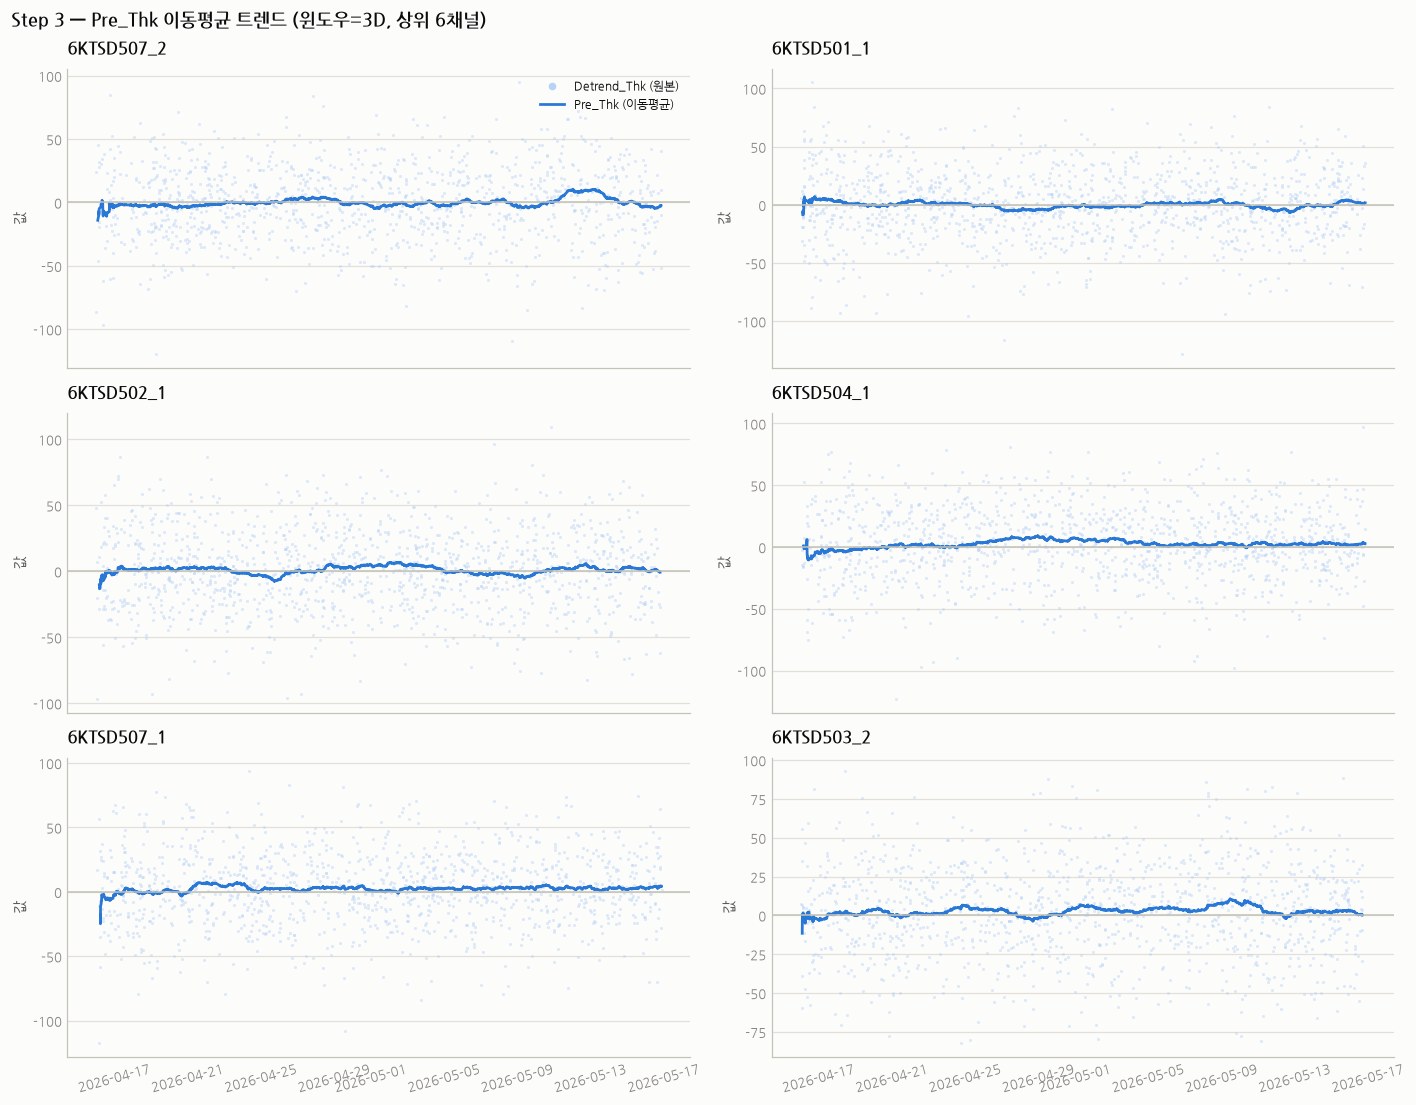

In [12]:
if use_moving_avg or use_itm:
    # 데이터 많은 순으로 최대 6개 채널의 트렌드 표시
    top_ch = (valid.groupby('pre_eq_ch')['Pre_Thk_Count'].max()
                   .sort_values(ascending=False).head(6).index.tolist())
    n_rows = (len(top_ch) + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 3.4 * n_rows), sharex=True, squeeze=False)
    fig.suptitle(f'Step 3 — Pre_Thk 이동평균 트렌드 (윈도우={Pre_Thk_Period}, 상위 {len(top_ch)}채널)',
                 fontsize=12, fontweight='bold', color=INK_PRIMARY, x=0.01, ha='left')

    axes_flat = axes.flatten()
    for ax, ch in zip(axes_flat, top_ch):
        raw = pre_df_rolled[pre_df_rolled['pre_eq_ch'] == ch]
        sub = valid[valid['pre_eq_ch'] == ch].sort_values('pre_oper_time')
        ax.scatter(raw['pre_oper_time'], raw[value_col], s=4, alpha=0.25, color=RAW_COLOR, linewidths=0)
        ax.plot(sub['pre_oper_time'], sub['Pre_Thk'], color=PALETTE[0], linewidth=1.8)
        ax.axhline(0, color=BASELINE, linewidth=1)
        style_ax(ax, title=ch, ylabel='값', legend=False)
        ax.tick_params(axis='x', rotation=15)
    for ax in axes_flat[len(top_ch):]:
        ax.set_visible(False)

    axes_flat[0].scatter([], [], s=16, color=RAW_COLOR, label=f'{value_col} (원본)')
    axes_flat[0].plot([], [], color=PALETTE[0], linewidth=1.8, label='Pre_Thk (이동평균)')
    axes_flat[0].legend(fontsize=8, frameon=False, loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print('회귀 전용 경로 — 이 단계는 건너뜁니다')

## Step 4 — `_extract_latest()` : 최신값 추출 → 최종 학습값

```python
# Common/Module.py
df['rank'] = df.groupby('pre_eq_ch')['pre_oper_time'].rank(method='first', ascending=False)
pre_thk_table = df[df['rank'] == 1]     # 채널별 가장 최근 1행만 최종 학습값으로 채택
```

운영 환경에서는 이 테이블이 MongoDB 컬렉션
`MICO_PRE_THK_{Lot_Code}_{Oper_Desc}_{Fab}_Period` 에 저장되어
Removal Rate 학습에서 전공정 두께 보정값으로 사용됩니다.

In [13]:
if use_moving_avg or use_itm:
    from Common.Module import _extract_latest

    pre_df_rolled['THK_Para'] = Thk_Para
    pre_thk_table = _extract_latest(
        pre_df_rolled, cols=['pre_oper_time', 'pre_eq_ch', 'Pre_Thk', 'Pre_Thk_Count', 'THK_Para']
    ).sort_values('pre_eq_ch').reset_index(drop=True)

    print(f'최종 Pre_Thk_VM 학습값: {len(pre_thk_table)}건 (채널별 최신 1건)')
    display(pre_thk_table)
else:
    pre_thk_table = pd.DataFrame([{'THK_Para': Thk_Para}])
    print('회귀 전용 경로 — 채널별 학습값 없음. Step 5(회귀)만 수행합니다.')

최종 Pre_Thk_VM 학습값: 16건 (채널별 최신 1건)


,pre_oper_time,pre_eq_ch,Pre_Thk,Pre_Thk_Count,THK_Para
0,2026-05-16 20:47:27.854184,6KTSD501_1,1.523787,225.0,AMAT_POST_OCD_AVG
1,2026-05-16 20:59:30.952848,6KTSD501_2,1.076548,207.0,AMAT_POST_OCD_AVG
2,2026-05-16 19:32:57.701049,6KTSD502_1,-0.633888,217.0,AMAT_POST_OCD_AVG
3,2026-05-16 17:07:43.145359,6KTSD502_2,2.273712,253.0,AMAT_POST_OCD_AVG
4,2026-05-16 19:47:37.603730,6KTSD503_1,-2.311504,187.0,AMAT_POST_OCD_AVG
5,2026-05-16 17:05:00.440990,6KTSD503_2,0.379371,255.0,AMAT_POST_OCD_AVG
6,2026-05-16 20:37:55.768739,6KTSD504_1,2.446816,229.0,AMAT_POST_OCD_AVG
7,2026-05-16 20:36:08.791777,6KTSD504_2,2.120270,209.0,AMAT_POST_OCD_AVG
8,2026-05-16 17:51:02.586333,6KTSD505_1,0.687661,227.0,AMAT_POST_OCD_AVG
9,2026-05-16 20:59:28.442040,6KTSD505_2,1.510235,245.0,AMAT_POST_OCD_AVG


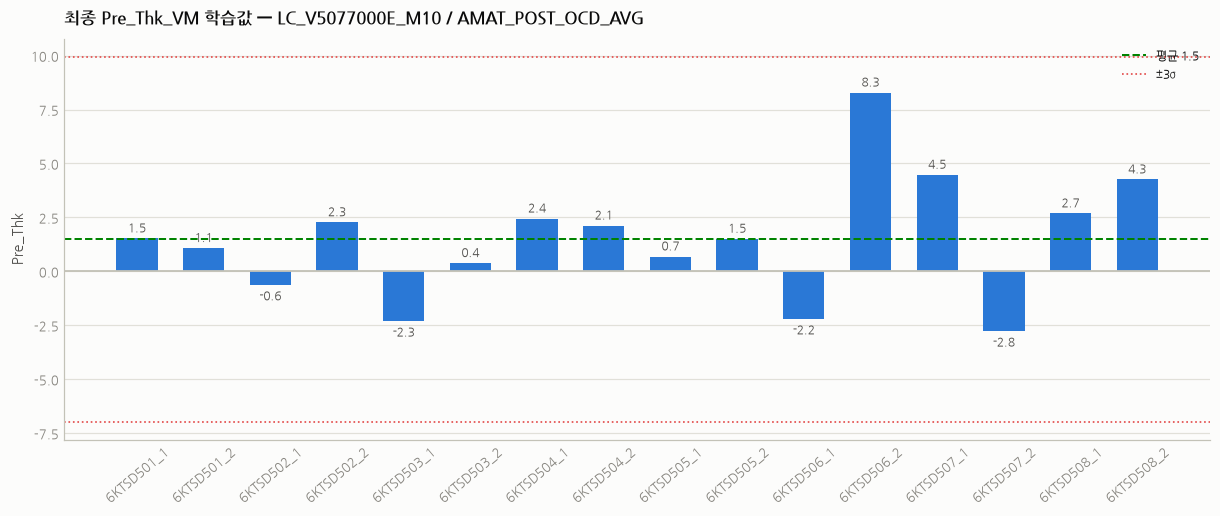

평균 1.49  |  표준편차 2.82  |  범위 -2.78 ~ 8.29


In [14]:
if (use_moving_avg or use_itm) and len(pre_thk_table) > 0:
    mean_v, std_v = pre_thk_table['Pre_Thk'].mean(), pre_thk_table['Pre_Thk'].std()
    n_ch = len(pre_thk_table)

    fig, ax = plt.subplots(figsize=(max(9, 0.7 * n_ch), 4.8))
    bars = ax.bar(pre_thk_table['pre_eq_ch'], pre_thk_table['Pre_Thk'], color=PALETTE[0], width=0.62)
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=3, color=INK_SECONDARY)
    ax.axhline(0, color=BASELINE, linewidth=1.2)
    ax.axhline(mean_v, color=PALETTE[3], linewidth=1.3, linestyle='--', label=f'평균 {mean_v:.1f}')
    if n_ch > 1:
        ax.axhline(mean_v + 3 * std_v, color=PALETTE[5], linewidth=1.1, linestyle=':')
        ax.axhline(mean_v - 3 * std_v, color=PALETTE[5], linewidth=1.1, linestyle=':', label='±3σ')
    style_ax(ax, title=f'최종 Pre_Thk_VM 학습값 — {FOR_KEY} / {Thk_Para}', ylabel='Pre_Thk')
    ax.tick_params(axis='x', rotation=40)

    plt.tight_layout()
    plt.show()
    print(f'평균 {mean_v:.2f}  |  표준편차 {std_v:.2f}  |  '
          f'범위 {pre_thk_table["Pre_Thk"].min():.2f} ~ {pre_thk_table["Pre_Thk"].max():.2f}')

## Step 5 — (설정된 경우) Pre_Oper2~4 회귀 학습

`Pre_Oper_Code2~4` 가 Set-up 에 있으면, 전공정 파라미터 값과 학습 대상값
(`BIAS` 또는 `Detrend_Thk`) 사이의 **단순선형회귀 계수(b1, b0)** 를 산출해
학습값 테이블에 추가합니다.

```python
# PRE_THK_VM.py  fit_pre_oper_regression()
merged    = merge(학습 대상값, 전공정 INFO 데이터, on='substrate_id')
lr        = LinearRegression().fit(X=전공정 파라미터, y=학습 대상값)
pre_thk_table['PRE_OPER2_b1'] = lr.coef_,  ['PRE_OPER2_b0'] = lr.intercept_
```

전공정 INFO 데이터는 MongoDB 컬렉션 `MICO_PRE_THK_INFO_{Lot_Code}_{Oper_Desc}_{Fab}`
에서 읽습니다 (Merge_Hub 가 미리 적재). **회사 서버에서 실행하면 그대로 동작하고**,
MongoDB 가 없거나 해당 공정에 Pre_Oper2 설정이 없으면 이 단계는 자동으로 건너뜁니다.

In [15]:
if has_regression:
    from pymongo import MongoClient
    from Common.Module import _MONGO_URL, _MONGO_DB

    ref_key        = key_df.iloc[0]
    oper_pairs = [
        (ref_key['Pre_Oper_Desc2'], ref_key['Pre_Oper_Para2'], 'PRE_OPER2'),
        (ref_key['Pre_Oper_Desc3'], ref_key['Pre_Oper_Para3'], 'PRE_OPER3'),
        (ref_key['Pre_Oper_Desc4'], ref_key['Pre_Oper_Para4'], 'PRE_OPER4'),
    ]

    try:
        client = MongoClient(_MONGO_URL)
        try:
            raw = client[_MONGO_DB]['MICO_PRE_THK_INFO_' + Lot_Code + '_' + Oper_Desc + '_' + Fab].find({}, {'_id': 0})
            pre2_df = pd.DataFrame(raw)
        finally:
            client.close()

        pre2_df = Get_data.coalesce_substrate_id(pre2_df)
        if 'substrate_id' in pre2_df.columns:
            pre2_df = pre2_df.drop_duplicates(subset='substrate_id', keep='last')

        print(f'전공정 INFO 데이터: {len(pre2_df):,}행')
        PRE_THK_VM_Get.fit_pre_oper_regression(pre_df_filtered, pre2_df, pre_thk_table, oper_pairs, value_col)

        reg_cols = [c for c in pre_thk_table.columns if c.startswith('PRE_OPER')]
        print(f'산출된 회귀계수: {reg_cols}')
        display(pre_thk_table)
    except Exception as e:
        print(f'회귀 산출 실패 (MongoDB 연결 필요 — 회사 서버에서 실행하세요): {e}')
else:
    print('Pre_Oper_Code2~4 미설정 — 이 공정은 회귀 학습 대상이 아닙니다 (건너뜀)')

Pre_Oper_Code2~4 미설정 — 이 공정은 회귀 학습 대상이 아닙니다 (건너뜀)


## 정리

| Step | 함수 | 입력 → 출력 |
|---|---|---|
| 경로 판단 | (Module.py 로직) | Set-up → ITM / Detrend+MA / 회귀 자동 분기 |
| 1 | `compute_detrend()` 또는 BIAS 계산 | 두께·연마시간 → 0-centered 학습 대상값 |
| 2 | `PRE_THK_VM_Get.iqr_filter()` | 학습 대상값 → 이상치 제거 |
| 3 | `PRE_THK_VM_Get.rolling_mean()` | 학습 대상값 → 채널별 Pre_Thk (이동평균) |
| 4 | `Common.Module._extract_latest()` | Pre_Thk → 채널별 최종 학습값 1건 |
| 5 | `fit_pre_oper_regression()` | 전공정 파라미터 → 회귀계수 b1/b0 (설정 시) |

실제 운영에서는 `Common/Module.py` 의 `Module_Get.compute_pre_thk_vm()` 이 위 단계를
Thk_Para 별로 모두 반복 실행한 뒤 MongoDB 에 저장하고, 이 학습값은
**Removal Rate 학습**(다음 교육 자료)에서 전공정 두께 보정값으로 사용됩니다.

> 다른 공정을 보려면 맨 위 [실행 설정] 셀에서 `FAMILY` / `OPER_DESC`
> (필요시 `KEY_INDEX` / `THK_INDEX`)만 바꾸고 전체 재실행하면 됩니다.